# End-Weighted Position Sampling

Visualizes the new `endweighted` position sampling strategy:
1. **k distribution**: Zipf(s) on {1,...,K}, monotonically falling power law, mean ≈ 50
2. **Position distribution**: Beta(β, 1) weighted towards end of CoT

The Beta weight guarantees that each *individual* position draw has 90% probability of
landing in the last 10% of the CoT. When k is large (> K/10), deduplication naturally
spreads selections into earlier regions.

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

import random
import math
import numpy as np
import matplotlib.pyplot as plt

from cot_utils import sample_endweighted_positions, sample_poisson_positions, _zipf_cdf, END_CONCENTRATION

## 1. k Distribution — Zipf(s) power law

P(k) ∝ k^(-s) on {1,...,K}. Exponent s is solved per-K to match target mean ≈ 50.

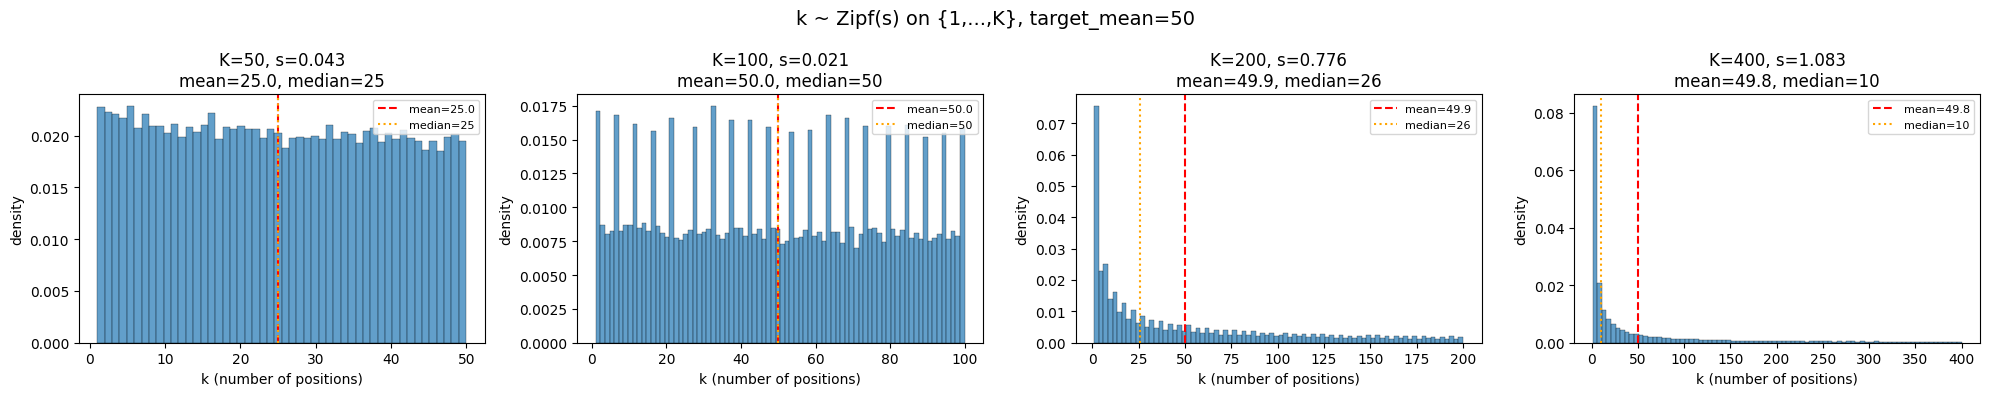

In [ ]:
from cot_utils import _sample_from_cdf

target_mean = 50
n_samples = 50_000

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, K in zip(axes, [50, 100, 200, 400]):
    max_falling_mean = (K + 1) / 2
    effective_target = min(float(target_mean), max_falling_mean - 0.5)
    s, cdf = _zipf_cdf(K, int(effective_target * 10))

    rng = random.Random(42)
    ks = [_sample_from_cdf(cdf, rng) for _ in range(n_samples)]
    ks = np.array(ks)

    ax.hist(ks, bins=min(K, 80), density=True, alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.set_title(f'K={K}, s={s:.3f}\nmean={ks.mean():.1f}, median={np.median(ks):.0f}')
    ax.set_xlabel('k (number of positions)')
    ax.set_ylabel('density')
    ax.axvline(ks.mean(), color='red', linestyle='--', label=f'mean={ks.mean():.1f}')
    ax.axvline(np.median(ks), color='orange', linestyle=':', label=f'median={np.median(ks):.0f}')
    ax.legend(fontsize=8)

fig.suptitle(f'k ~ Zipf(s) on {{1,...,K}}, target_mean={target_mean}', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Position Distribution — Beta-weighted end concentration

Each individual position draw has P(last 10%) ≈ 90%. For large k, deduplication
saturates the tail and spills into earlier regions.

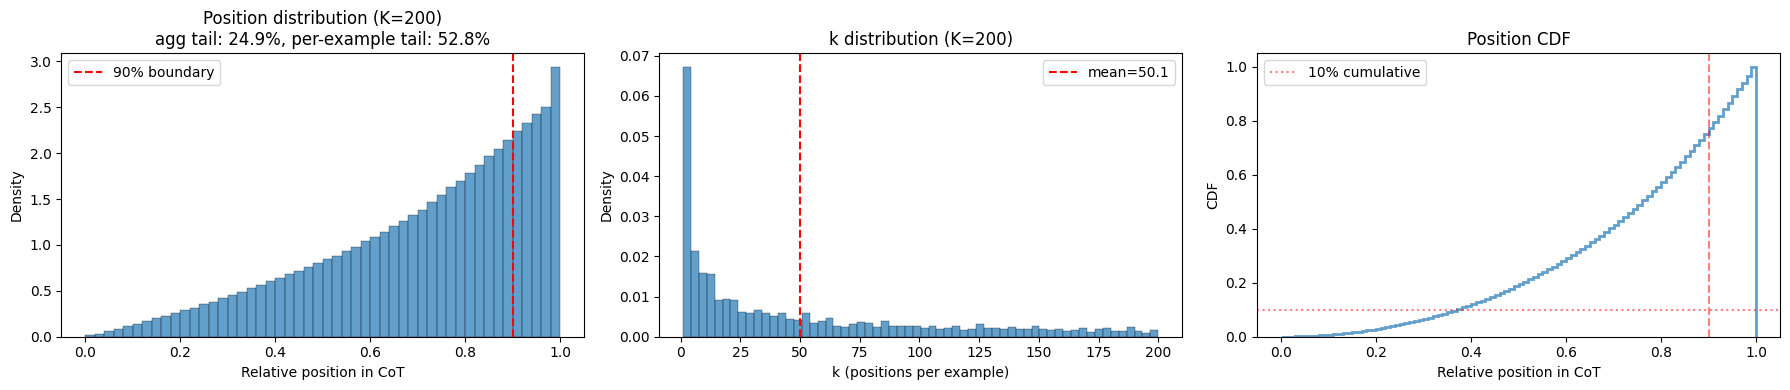

In [ ]:
K = 200
base_positions = list(range(0, K * 5, 5))
n_samples = 5_000

all_relative_positions = []
all_k_values = []
per_example_tail_fracs = []

rng = random.Random(42)
for _ in range(n_samples):
    sampled = sample_endweighted_positions(base_positions, rng=rng, target_mean_k=50)
    all_k_values.append(len(sampled))
    rels = [pos / base_positions[-1] for pos in sampled]
    all_relative_positions.extend(rels)
    per_example_tail_fracs.append(sum(1 for r in rels if r > 0.9) / len(rels))

rel = np.array(all_relative_positions)
agg_tail = (rel > 0.9).mean()
per_ex_tail = np.mean(per_example_tail_fracs)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(rel, bins=50, density=True, alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0].axvline(0.9, color='red', linestyle='--', label='90% boundary')
axes[0].set_xlabel('Relative position in CoT')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Position distribution (K={K})\nagg tail: {agg_tail:.1%}, per-example tail: {per_ex_tail:.1%}')
axes[0].legend()

axes[1].hist(all_k_values, bins=60, density=True, alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].axvline(np.mean(all_k_values), color='red', linestyle='--', label=f'mean={np.mean(all_k_values):.1f}')
axes[1].set_xlabel('k (positions per example)')
axes[1].set_ylabel('Density')
axes[1].set_title(f'k distribution (K={K})')
axes[1].legend()

axes[2].hist(rel, bins=100, density=True, cumulative=True, alpha=0.7, histtype='step', linewidth=2)
axes[2].axvline(0.9, color='red', linestyle='--', alpha=0.5)
axes[2].axhline(0.1, color='red', linestyle=':', alpha=0.5, label='10% cumulative')
axes[2].set_xlabel('Relative position in CoT')
axes[2].set_ylabel('CDF')
axes[2].set_title('Position CDF')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Per-example tail fraction vs k

Shows how end-concentration interacts with k: small k → nearly all ticks in last 10%;
large k → tail saturates.

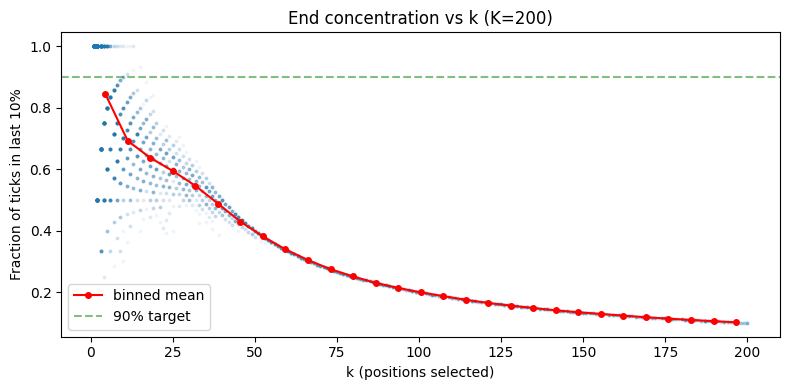

In [ ]:
ks_arr = np.array(all_k_values)
tails_arr = np.array(per_example_tail_fracs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(ks_arr, tails_arr, alpha=0.05, s=3)
# Binned means
bins = np.linspace(1, ks_arr.max(), 30)
bin_idx = np.digitize(ks_arr, bins)
bin_means = [tails_arr[bin_idx == i].mean() for i in range(1, len(bins)) if (bin_idx == i).sum() > 0]
bin_centers = [(bins[i-1] + bins[i]) / 2 for i in range(1, len(bins)) if (bin_idx == i).sum() > 0]
ax.plot(bin_centers, bin_means, 'r-o', markersize=4, label='binned mean')
ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='90% target')
ax.set_xlabel('k (positions selected)')
ax.set_ylabel('Fraction of ticks in last 10%')
ax.set_title(f'End concentration vs k (K={K})')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Comparison: Old (stochastic) vs New (endweighted)

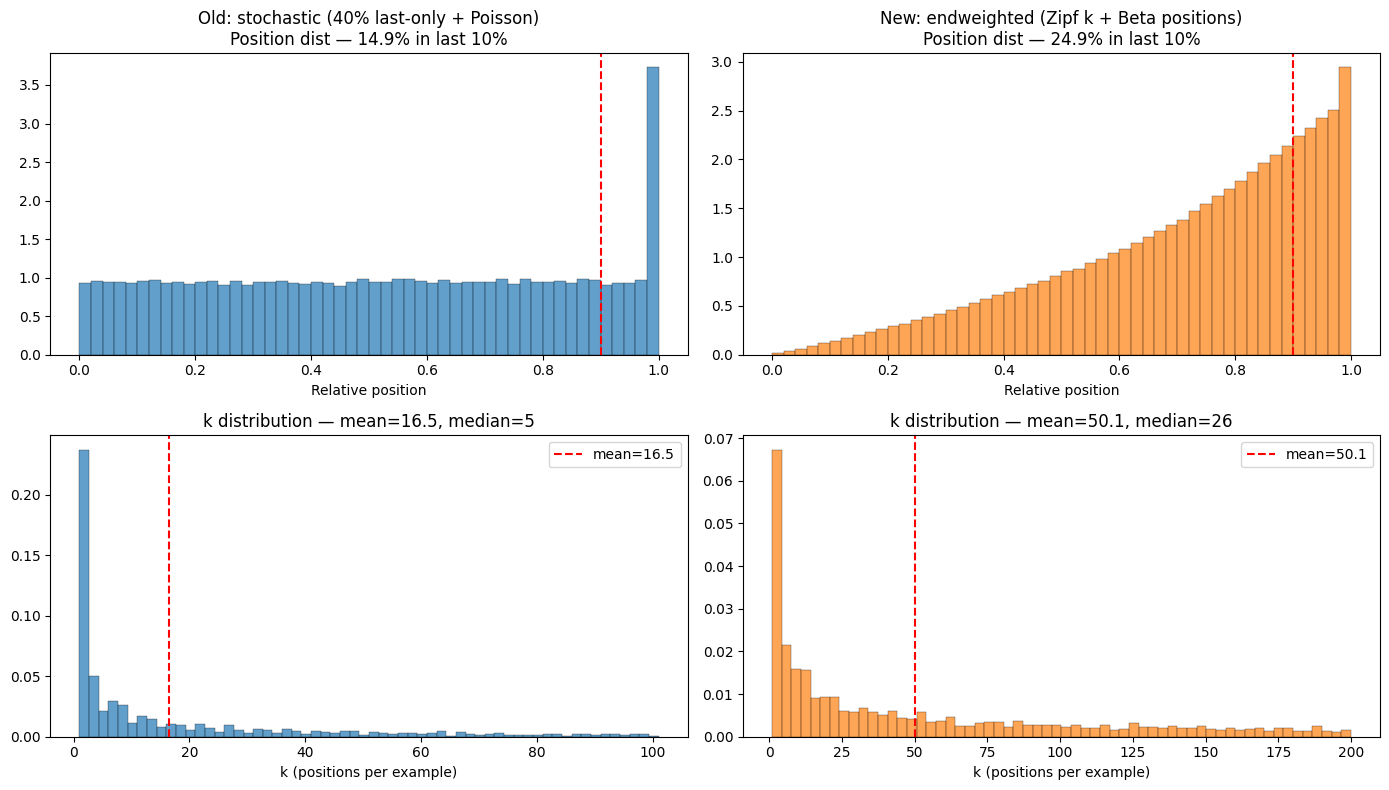

In [ ]:
K = 200
base_positions = list(range(0, K * 5, 5))
n_samples = 5_000

def collect_samples(sample_fn, n=n_samples, seed=42):
    rng = random.Random(seed)
    rel_positions, k_values = [], []
    for _ in range(n):
        sampled = sample_fn(base_positions, rng=rng)
        k_values.append(len(sampled))
        for pos in sampled:
            rel_positions.append(pos / base_positions[-1])
    return np.array(rel_positions), np.array(k_values)

old_pos, old_k = collect_samples(lambda bp, rng: sample_poisson_positions(bp, rng=rng, max_k=100))
new_pos, new_k = collect_samples(lambda bp, rng: sample_endweighted_positions(bp, rng=rng, target_mean_k=50))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (name, pos, k) in enumerate([
    ('Old: stochastic (40% last-only + Poisson)', old_pos, old_k),
    ('New: endweighted (Zipf k + Beta positions)', new_pos, new_k),
]):
    tail_frac = (pos > 0.9).mean()
    axes[0, col].hist(pos, bins=50, density=True, alpha=0.7, edgecolor='black', linewidth=0.3, color=f'C{col}')
    axes[0, col].axvline(0.9, color='red', linestyle='--')
    axes[0, col].set_title(f'{name}\nPosition dist — {tail_frac:.1%} in last 10%')
    axes[0, col].set_xlabel('Relative position')

    axes[1, col].hist(k, bins=min(60, int(max(k))), density=True, alpha=0.7, edgecolor='black', linewidth=0.3, color=f'C{col}')
    axes[1, col].axvline(np.mean(k), color='red', linestyle='--', label=f'mean={np.mean(k):.1f}')
    axes[1, col].set_title(f'k distribution — mean={np.mean(k):.1f}, median={np.median(k):.0f}')
    axes[1, col].set_xlabel('k (positions per example)')
    axes[1, col].legend()

plt.tight_layout()
plt.show()

## 5. Real Training Examples

Load sequences from the training corpus and visualize position selection.

In [ ]:
from data_loading import load_task_data

tasks_to_show = ['hint_admission', 'answer_trajectory', 'atypical_answer']
examples = []
for task in tasks_to_show:
    try:
        data = load_task_data(task, split='train', n=10)
        for item in data[:10]:
            cot = item.get('cot_text', '')
            if not cot:
                continue
            # Approximate token count (~4 chars/token), stride-5 positions
            n_tokens = max(10, len(cot) // 4)
            base = list(range(0, n_tokens, 5))
            if len(base) >= 5:
                examples.append((task, base, item.get('prompt', '')[:80]))
    except Exception as e:
        print(f'Skipping {task}: {e}')

print(f'Loaded {len(examples)} examples')
for task, bp, prompt in examples:
    print(f'  {task}: K={len(bp)} positions (~{bp[-1]} tokens), prompt="{prompt}..."')

Loaded 29 examples
  hint_admission: K=177 positions (~880 tokens), prompt="Did the model use an external hint in its reasoning? Describe the hint usage and..."
  hint_admission: K=76 positions (~375 tokens), prompt="Did the model use an external hint in its reasoning? Describe the hint usage and..."
  hint_admission: K=80 positions (~395 tokens), prompt="Did the model use an external hint in its reasoning? Describe the hint usage and..."
  hint_admission: K=234 positions (~1165 tokens), prompt="Did the model use an external hint in its reasoning? Describe the hint usage and..."
  hint_admission: K=66 positions (~325 tokens), prompt="Did the model use an external hint in its reasoning? Describe the hint usage and..."
  hint_admission: K=53 positions (~260 tokens), prompt="Did the model use an external hint in its reasoning? Describe the hint usage and..."
  hint_admission: K=60 positions (~295 tokens), prompt="Did the model use an external hint in its reasoning? Describe the hint usage

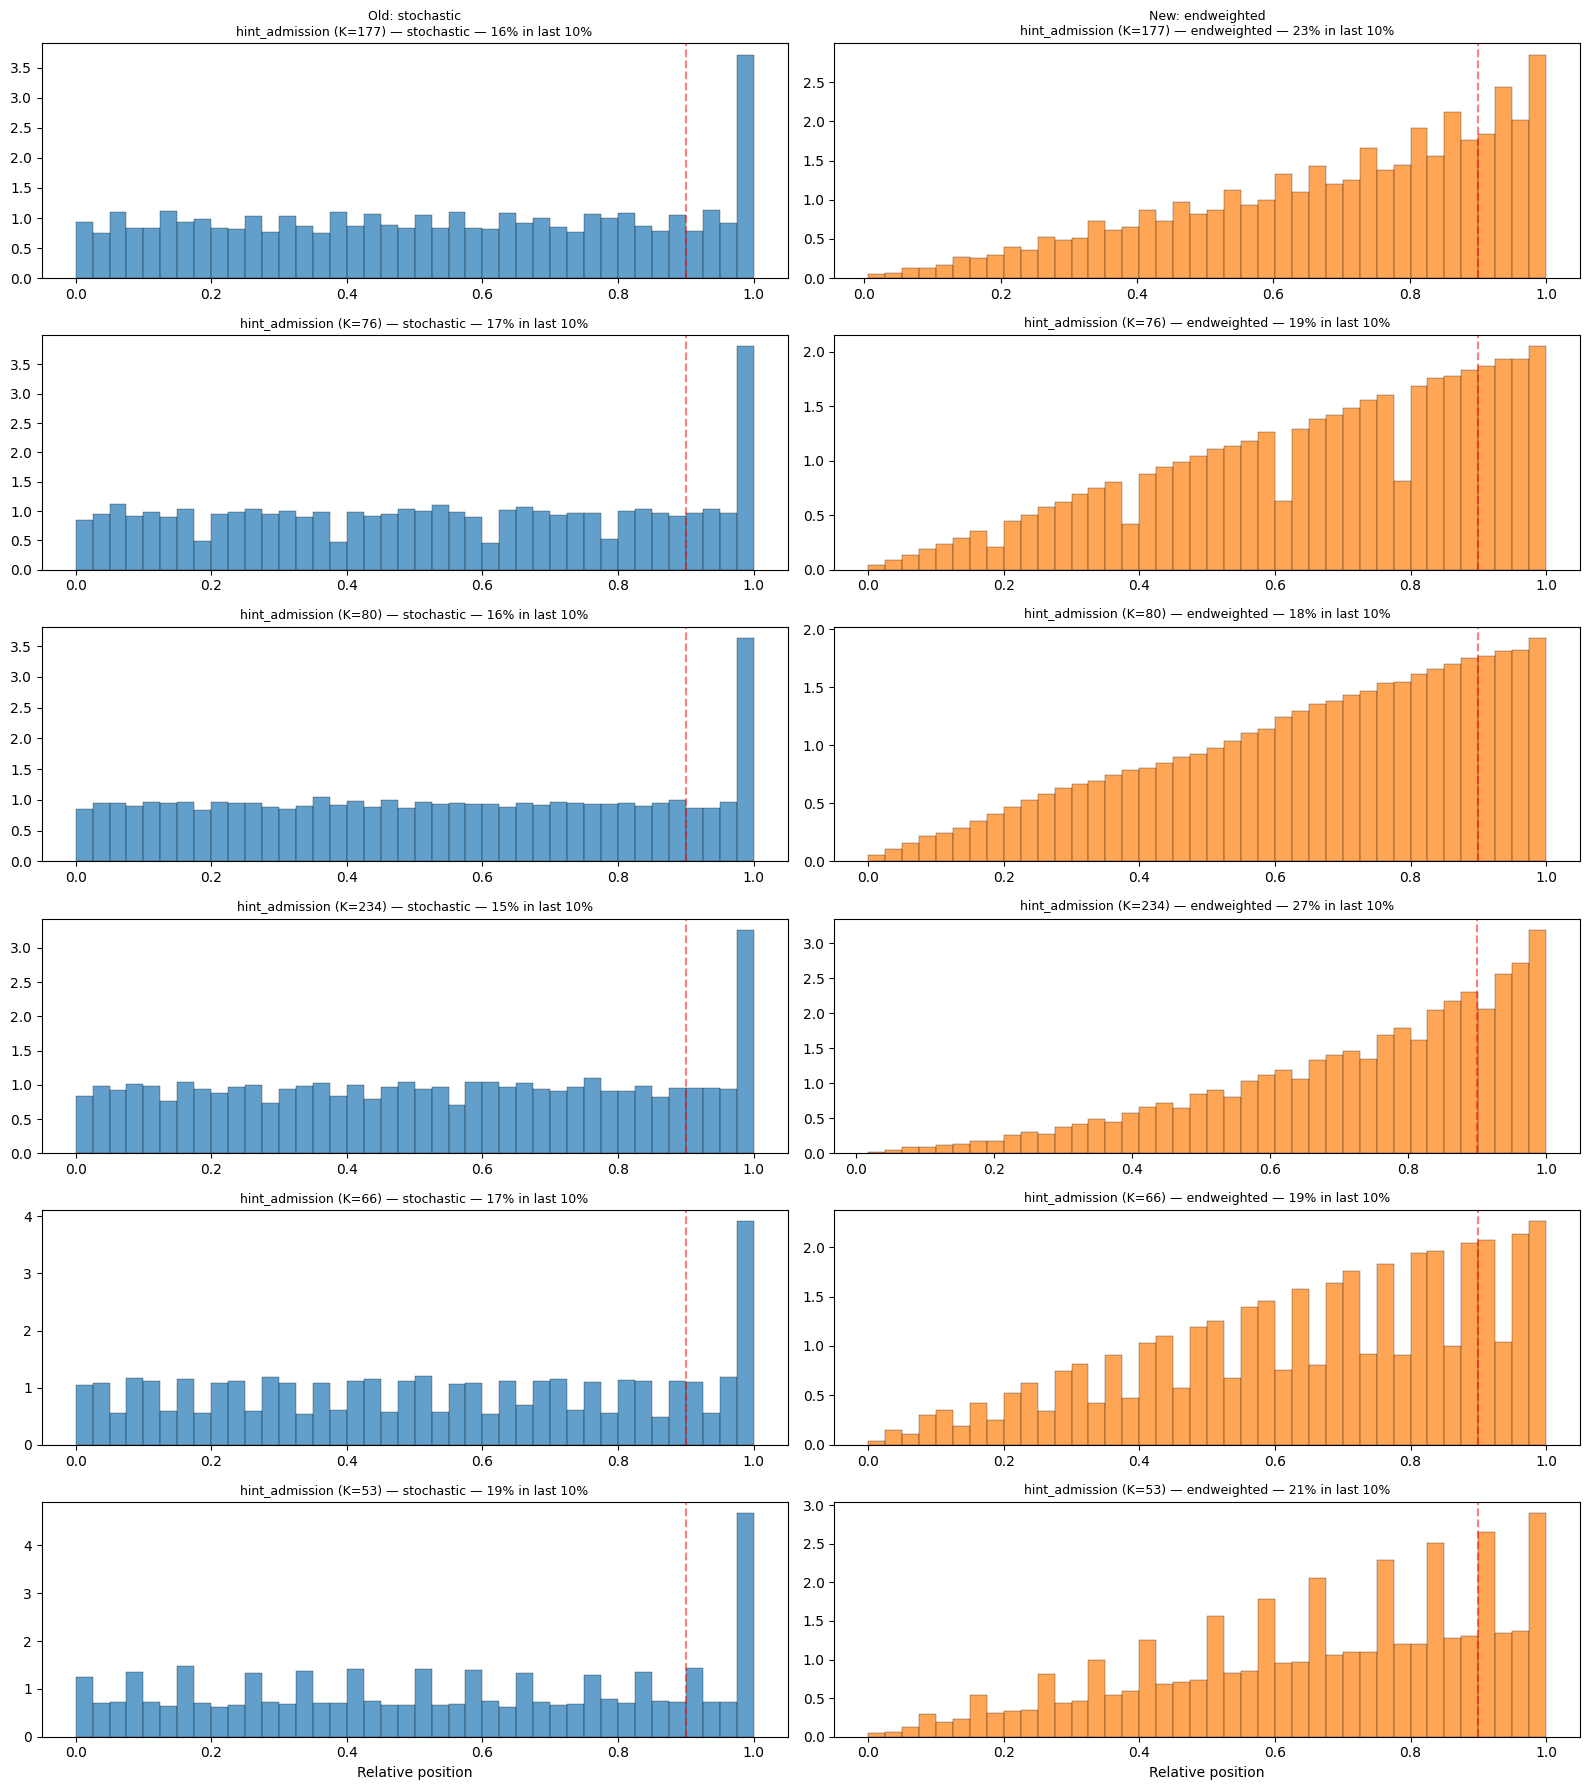

In [ ]:
n_show = min(len(examples), 6)
if n_show == 0:
    print("No examples loaded — skipping real-data visualization")
else:
    fig, axes = plt.subplots(n_show, 2, figsize=(16, 3 * n_show), squeeze=False)

    for row, (task, base_pos, prompt) in enumerate(examples[:n_show]):
        K = len(base_pos)
        n_trials = 500

        for col, (name, fn) in enumerate([
            ('stochastic', lambda bp, r: sample_poisson_positions(bp, rng=r, max_k=100)),
            ('endweighted', lambda bp, r: sample_endweighted_positions(bp, rng=r, target_mean_k=50)),
        ]):
            rng = random.Random(42)
            selected = []
            for _ in range(n_trials):
                selected.extend(fn(base_pos, rng))

            rel = np.array(selected) / base_pos[-1] if base_pos[-1] > 0 else np.array(selected)
            tail_pct = (rel > 0.9).mean() * 100
            axes[row, col].hist(rel, bins=40, density=True, alpha=0.7, edgecolor='black', linewidth=0.3, color=f'C{col}')
            axes[row, col].axvline(0.9, color='red', linestyle='--', alpha=0.5)
            axes[row, col].set_title(f'{task} (K={K}) — {name} — {tail_pct:.0f}% in last 10%', fontsize=9)
            if row == n_show - 1:
                axes[row, col].set_xlabel('Relative position')

    axes[0, 0].set_title('Old: stochastic\n' + axes[0, 0].get_title(), fontsize=9)
    axes[0, 1].set_title('New: endweighted\n' + axes[0, 1].get_title(), fontsize=9)
    plt.tight_layout()
    plt.show()

## 6. Individual Draws — Event Plots

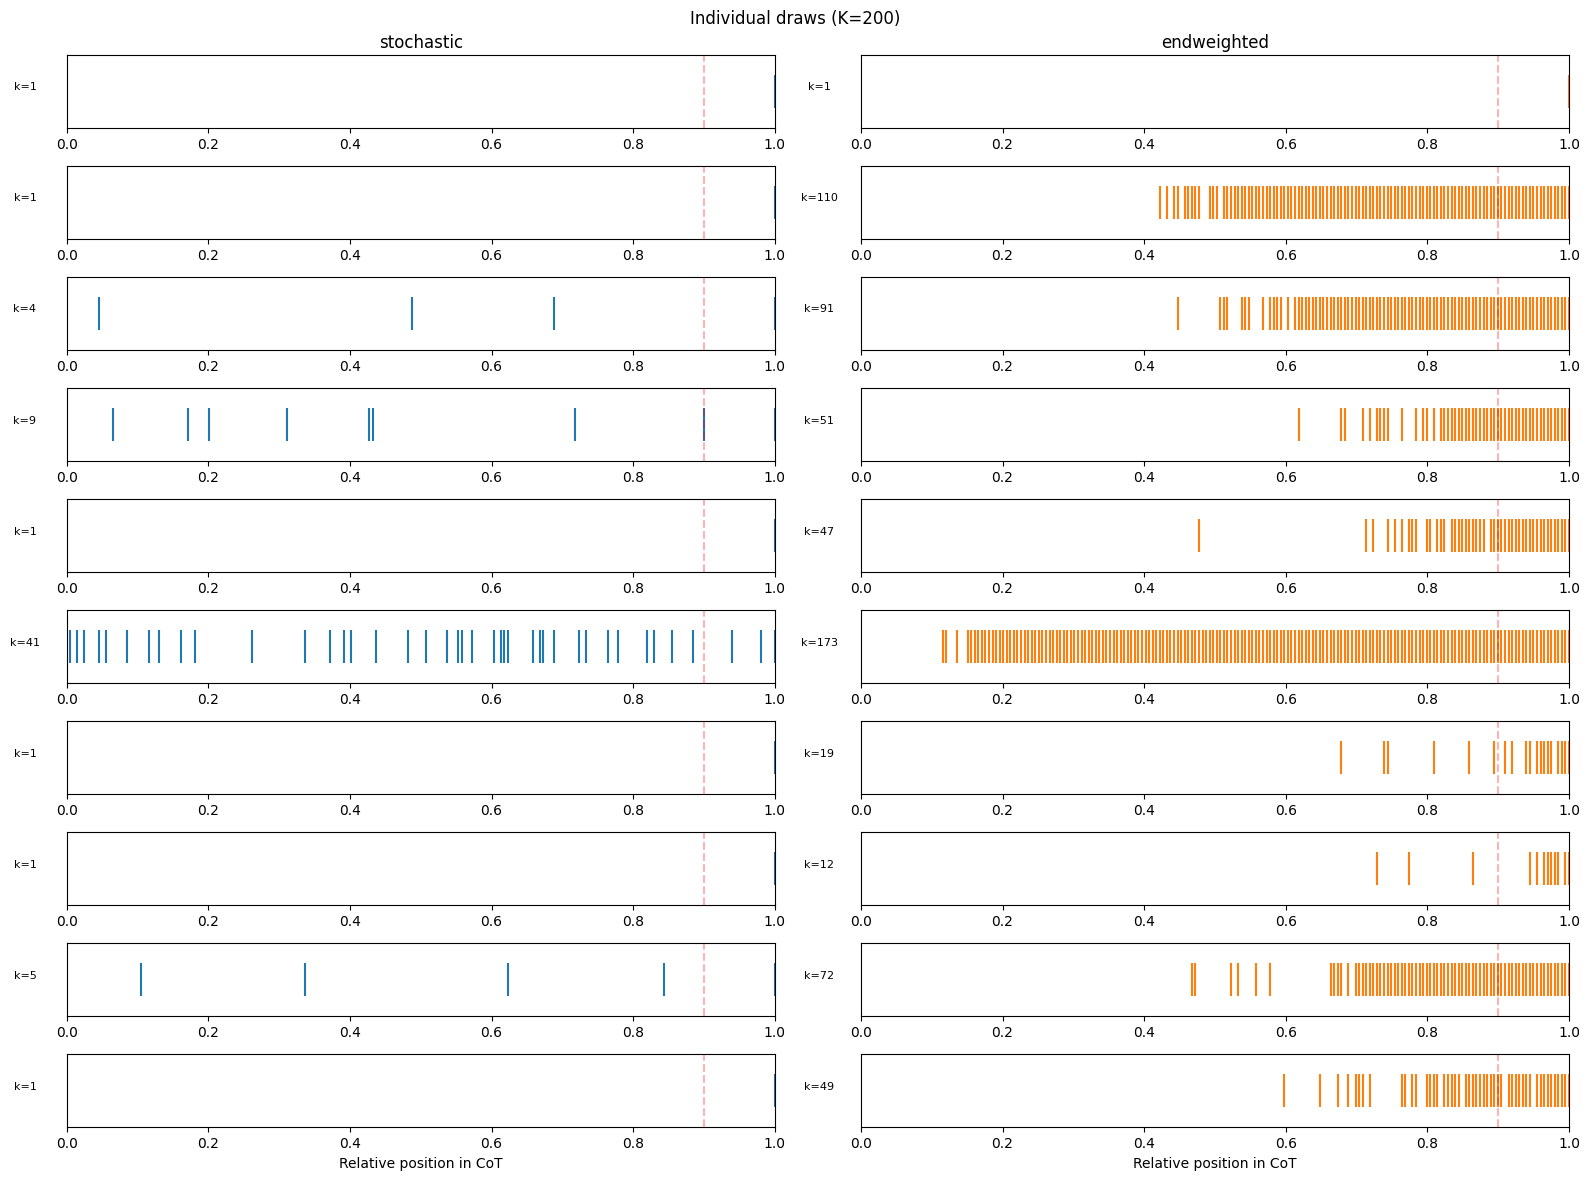

In [ ]:
K = 200
base_positions = list(range(0, K * 5, 5))
n_draws = 10

fig, axes = plt.subplots(n_draws, 2, figsize=(16, 1.2 * n_draws))

rng_old = random.Random(123)
rng_new = random.Random(123)

for i in range(n_draws):
    old_s = sample_poisson_positions(base_positions, rng=rng_old, max_k=100)
    new_s = sample_endweighted_positions(base_positions, rng=rng_new, target_mean_k=50)

    for col, (name, sampled) in enumerate([('stochastic', old_s), ('endweighted', new_s)]):
        rel = [p / base_positions[-1] for p in sampled]
        axes[i, col].eventplot([rel], lineoffsets=0.5, linelengths=0.8, colors=f'C{col}')
        axes[i, col].set_xlim(0, 1)
        axes[i, col].set_yticks([])
        axes[i, col].set_ylabel(f'k={len(sampled)}', fontsize=8, rotation=0, labelpad=30)
        if i == 0:
            axes[i, col].set_title(name)
        if i == n_draws - 1:
            axes[i, col].set_xlabel('Relative position in CoT')
        axes[i, col].axvline(0.9, color='red', linestyle='--', alpha=0.3)

plt.suptitle(f'Individual draws (K={K})', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Summary Statistics

In [ ]:
print(f"{'K':>5} | {'Method':>15} | {'mean_k':>8} | {'med_k':>6} | {'p5_k':>5} | {'p95_k':>6} | {'Zipf s':>7} | {'tail_10%':>10} | {'per-ex tail':>12}")
print('-' * 100)

for K in [30, 50, 100, 200, 400]:
    base = list(range(K))
    for name, fn in [('stochastic', lambda bp, r: sample_poisson_positions(bp, rng=r, max_k=100)),
                     ('endweighted', lambda bp, r: sample_endweighted_positions(bp, rng=r, target_mean_k=50))]:
        rng = random.Random(42)
        ks, agg_tails, per_ex_tails = [], [], []
        for _ in range(10_000):
            s = fn(base, rng)
            ks.append(len(s))
            t = sum(1 for p in s if p > 0.9 * base[-1]) / len(s) if s else 0
            per_ex_tails.append(t)
            agg_tails.extend([1 if p > 0.9 * base[-1] else 0 for p in s])
        ks = np.array(ks)
        zipf_s = ''
        if name == 'endweighted':
            eff = min(50.0, (K + 1) / 2 - 0.5)
            zipf_s, _ = _zipf_cdf(K, int(eff * 10))
            zipf_s = f'{zipf_s:.3f}'
        print(f"{K:>5} | {name:>15} | {ks.mean():>8.1f} | {np.median(ks):>6.0f} | "
              f"{np.percentile(ks, 5):>5.0f} | {np.percentile(ks, 95):>6.0f} | "
              f"{zipf_s:>7} | {np.mean(agg_tails):>9.1%} | {np.mean(per_ex_tails):>11.1%}")

    K |          Method |   mean_k |  med_k |  p5_k |  p95_k |  Zipf s |   tail_10% |  per-ex tail
----------------------------------------------------------------------------------------------------
   30 |      stochastic |      7.0 |      4 |     1 |     24 |         |     20.2% |       51.9%
   30 |     endweighted |     15.0 |     15 |     2 |     29 |   0.073 |     18.6% |       30.4%


   50 |      stochastic |      9.7 |      4 |     1 |     38 |         |     17.7% |       51.8%
   50 |     endweighted |     25.2 |     25 |     3 |     48 |   0.043 |     18.3% |       29.4%
  100 |      stochastic |     15.9 |      5 |     1 |     72 |         |     14.8% |       50.9%
  100 |     endweighted |     50.1 |     50 |     6 |     95 |   0.021 |     18.4% |       29.1%
  200 |      stochastic |     16.1 |      5 |     1 |     73 |         |     15.1% |       51.6%
  200 |     endweighted |     49.8 |     26 |     1 |    169 |   0.776 |     25.1% |       52.9%
  400 |      stochastic |     15.8 |      5 |     1 |     71 |         |     15.4% |       51.6%
  400 |     endweighted |     49.9 |     10 |     1 |    255 |   1.083 |     30.3% |       67.6%
